In [2]:
import pandas as pd
import glob
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Thermal Sensitivity of National Power Grids

## Analyzing the Mathematical Relationship between Meteorological Factors and Electrical Load in Bulgaria (BG)

Author: Aleksandar Ginev  
Project Type: Technical Report / Data Science Research  

---

## Abstract

This research investigates the correlation between ambient temperature and electrical load within the Bulgarian (BG) power grid. Using high-resolution hourly data from the ENTSO-E Transparency Platform and Meteostat, we construct a mathematical model to quantify Thermal Sensitivity—defined as the change in Megawatts (MW) per degree Celsius.

The analysis explores the non-linear U-Curve of energy demand, identifying the threshold at which heating and cooling systems dominate grid load. Furthermore, we apply these findings to a seasonal storage model to estimate the energy reserves required in summer to mitigate high-cost winter peaks.

Results demonstrate that weather-driven factors explain a significant percentage of load volatility, providing a roadmap for strategic energy arbitrage and grid stability.

---

## Table of Contents

1. Introduction & Problem Formulation  
2. Data Acquisition & Vetting  
3. Mathematical Foundations  
4. Data Pre-processing & Consolidation  
5. Exploratory Data Analysis (EDA)  
6. Modeling & Hypothesis Testing  
7. Predictive Strategy: Seasonal Energy Storage  
8. Results & Interpretation  
9. Conclusion & References  

---

## 1. Introduction & Problem Formulation

### 1.1 The Problem

Energy grid operators must maintain a real-time equilibrium between supply and demand. In the Bulgarian context, rapid temperature fluctuations often lead to unforeseen spikes in consumption. This project quantifies the "chaos factor" introduced by meteorological variables.

### 1.2 Objectives

- Merge and validate independent energy and weather datasets  
- Mathematically define the Point of Minimum Sensitivity for the Bulgarian grid  
- Model the impact of wind chill on perceived thermal load  

---


## 2. Data Acquisition & Vetting

-  ENTSO-E (Actual Total Load - BG)  
-  Meteostat (Hourly Meteorological Data - Sofia Station)  

### Validation Steps

- Handle missing values (NaNs)  
- Synchronize timestamps (UTC alignment)  

---

In [3]:
df_energy = pd.read_csv('bulgaria_load_2024_2025_full.csv')
df_weather = pd.read_csv('weather_master.csv')

df_energy = df_energy.rename(columns={'DateTime(UTC)': 'timestamp'})
df_energy['timestamp'] = pd.to_datetime(df_energy['timestamp'], utc=True).dt.tz_localize(None)

df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'], utc=True).dt.tz_localize(None)

df_energy = df_energy.sort_values('timestamp').drop_duplicates(subset=['timestamp'])
df_energy['TotalLoad[MW]'] = df_energy['TotalLoad[MW]'].interpolate(method='linear')

df_weather = df_weather.sort_values('timestamp').drop_duplicates(subset=['timestamp'])
df_weather['temp'] = df_weather['temp'].interpolate(method='linear', limit_direction='both')

print(f"Dataset energy Vetted: {len(df_energy)} hourly rows loaded.")
print(df_energy.head())

print(f"Dataset weather Vetted: {len(df_weather)} hourly rows loaded.")
print(df_weather.head())


Dataset energy Vetted: 17544 hourly rows loaded.
            timestamp ResolutionCode          AreaCode AreaDisplayName  \
0 2024-01-01 00:00:00          PT60M  10YCA-BULGARIA-R   Bulgaria (BG)   
1 2024-01-01 01:00:00          PT60M  10YCA-BULGARIA-R   Bulgaria (BG)   
2 2024-01-01 02:00:00          PT60M  10YCA-BULGARIA-R   Bulgaria (BG)   
3 2024-01-01 03:00:00          PT60M  10YCA-BULGARIA-R   Bulgaria (BG)   
4 2024-01-01 04:00:00          PT60M  10YCA-BULGARIA-R   Bulgaria (BG)   

  AreaTypeCode AreaMapCode  TotalLoad[MW]      UpdateTime(UTC)  
0  BZN/CTA/CTY          BG        3743.14  2025-08-10 09:14:20  
1  BZN/CTA/CTY          BG        3608.08  2025-08-10 09:14:20  
2  BZN/CTA/CTY          BG        3521.38  2025-08-10 09:14:20  
3  BZN/CTA/CTY          BG        3486.74  2025-08-10 09:14:20  
4  BZN/CTA/CTY          BG        3496.48  2025-08-10 09:14:20  
Dataset weather Vetted: 17544 hourly rows loaded.
            timestamp  temp  rhum  wspd    pres
0 2024-01-01 00:00

## 3. Mathematical Foundations

### 3.1 The U-Curve & Piecewise Linear Response

The relationship between ambient temperature ($T$) and electrical load ($L$) is fundamentally non-linear. The Bulgarian national grid exhibits a **U-shaped demand curve**.

To analyze this, we mathematically divide the temperature spectrum into three distinct thermal zones:

* **The Heating Zone ($T < T_{base}$):**
  A negative linear relationship where demand rises as temperatures drop, driven by resistive heating and heat pump activation.

* **The "Dead Band" (Comfort Zone):**
  A range of moderate temperatures (typically $15^\circ\text{C}$ to $22^\circ\text{C}$) where the derivative of load with respect to temperature is near zero:
  $$
  \frac{dL}{dT} \approx 0
  $$

* **The Cooling Zone ($T > T_{base_cooling}$):**
  A positive linear relationship where demand rises alongside temperature due to refrigeration and air conditioning.

---

### 3.2 Heating/Cooling Degree Days (HDD/CDD)

To linearize the U-Curve for regression analysis, we decompose the temperature variable into Degree Days. This allows us to quantify the "thermal work" required by the grid relative to a baseline comfort temperature.

* **Heating Degree Days (HDD):**
  Measures the magnitude of the thermal deficit:
  $$
  HDD = \max(0, T_{base} - T_{actual})
  $$

* **Cooling Degree Days (CDD):**
  Measures the magnitude of the thermal surplus:
  $$
  CDD = \max(0, T_{actual} - T_{base_cooling})
  $$

---

### 3.3 Pearson Correlation Coefficient ($r$)

We utilize the Pearson Correlation Coefficient to quantify the strength of the relationship between meteorological variables ($T$, $T_{wc}$, $HDD$) and the grid load ($L$). This ensures features are statistically significant before modeling.

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
$$

* $r \in [-1, 1]$:
  Where $-1$ indicates a perfect inverse correlation and $1$ indicates a perfect direct correlation.

---

### 3.4 Wind Chill Index ($T_{wc}$)

To account for convective heat loss in buildings during high-wind events, we calculate the Wind Chill Index. This serves as a "perceived temperature" feature that often provides a higher correlation to winter load than dry-bulb temperature alone:

$$
T_{wc} = 13.12 + 0.6215T - 11.37v^{0.16} + 0.3965Tv^{0.16}
$$

Where:

* $T$ = ambient temperature (°C)
* $v$ = wind speed (km/h)


---

## 4. Data Pre-processing & Consolidation

---

### 4.1 Temporal Inner Join and Synchronization

The first step in the consolidation pipeline is to align the two independent datasets. Since grid load and weather observations are reported from different sources (ENTSO-E and Meteostat), a **temporal inner join** is performed on the standardized hourly timestamp.

This ensures that every observation in the final research dataset contains both:

* a validated electrical load measurement
* a corresponding meteorological reading

Only overlapping timestamps are retained, guaranteeing full data integrity across modalities.

---

### 4.2 Feature Engineering: Thermal Indices

To capture the non-linear relationship between temperature and energy demand, we construct domain-specific thermal features.

#### Heating/Cooling Degree Days (HDD/CDD)

A **"Dead Band" strategy** is implemented using:

* heating base: $17^\circ\text{C}$
* cooling base: $22^\circ\text{C}$

This transforms the U-shaped temperature-load relationship into separable linear components suitable for regression modeling.

* **Heating Degree Days (HDD):**
  $$
  HDD = \max(0, 17 - T)
  $$

* **Cooling Degree Days (CDD):**
  $$
  CDD = \max(0, T - 22)
  $$

---

#### Wind Chill Index ($T_{wc}$)

The wind chill feature is selectively applied for temperatures:

$$
T \le 10^\circ\text{C}
$$

This accounts for convective heat loss in buildings, which significantly affects winter electricity demand in Bulgaria. The adjusted temperature is computed using the standard wind chill formulation:

$$
T_{wc} = 13.12 + 0.6215T - 11.37v^{0.16} + 0.3965Tv^{0.16}
$$

---

### 4.3 Behavioral Engineering: The Weekend Effect

A binary feature **`is_weekend`** is introduced to isolate behavioral and economic patterns from meteorological effects.

This accounts for structural demand differences caused by:

* reduced industrial activity
* lower commercial consumption
* altered weekday vs. weekend scheduling

By explicitly modeling this effect, the model avoids incorrectly attributing systematic demand drops to weather variability.

---

---

In [4]:

df_master = pd.merge(df_energy, df_weather, on='timestamp', how='inner')


df_master['month'] = df_master['timestamp'].dt.month
df_master['hour'] = df_master['timestamp'].dt.hour
df_master['is_weekend'] = df_master['timestamp'].dt.dayofweek >= 5


T_BASE_HEATING = 17.0
T_BASE_COOLING = 22.0

df_master['HDD'] = df_master['temp'].apply(lambda x: max(0, T_BASE_HEATING - x))
df_master['CDD'] = df_master['temp'].apply(lambda x: max(0, x - T_BASE_COOLING))

def apply_wind_chill(row):
    T, V = row['temp'], row['wspd']
    if T <= 10 and V > 4.8:
        return 13.12 + (0.6215 * T) - (11.37 * (V**0.16)) + (0.3965 * T * (V**0.16))
    return T

df_master['temp_wc'] = df_master.apply(apply_wind_chill, axis=1)

df_master.to_csv('bulgaria_master_research_data.csv', index=False)

print("-" * 30)
print(f"CONSOLIDATION SUCCESSFUL")
print(f"Synchronized Observations: {len(df_master)}")
print(f"New Features Created: HDD, CDD, temp_wc, is_weekend")
print("-" * 30)

------------------------------
CONSOLIDATION SUCCESSFUL
Synchronized Observations: 17544
New Features Created: HDD, CDD, temp_wc, is_weekend
------------------------------


# 5. Exploratory Data Analysis (EDA)
## 5.1 Feature Correlation Analysis
Before modeling, we must verify the strength of the relationship between our engineered features and the grid load. Using the Pearson Correlation Coefficient ($r$), we compare raw temperature against our Wind Chill and HDD features.

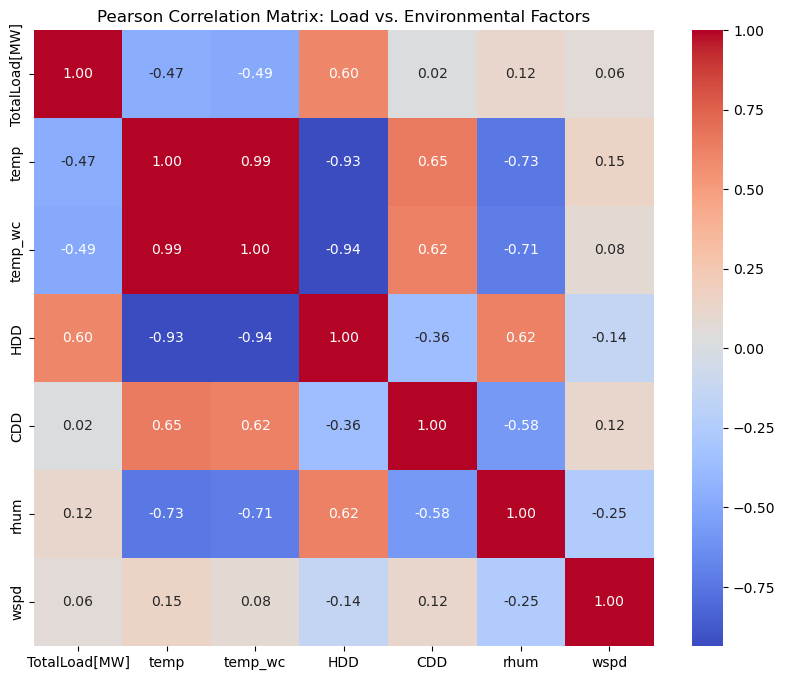

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['TotalLoad[MW]', 'temp', 'temp_wc', 'HDD', 'CDD', 'rhum', 'wspd']
correlation_matrix = df_master[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix: Load vs. Environmental Factors')
plt.show()

## 5.2 The Bulgarian "U-Curve"
The primary hypothesis of this study is the existence of a U-shaped demand curve. By plotting Temperature against Total Load, we can clearly visualize the "Dead Band" (Point of Minimum Sensitivity) where electricity demand is at its baseline.

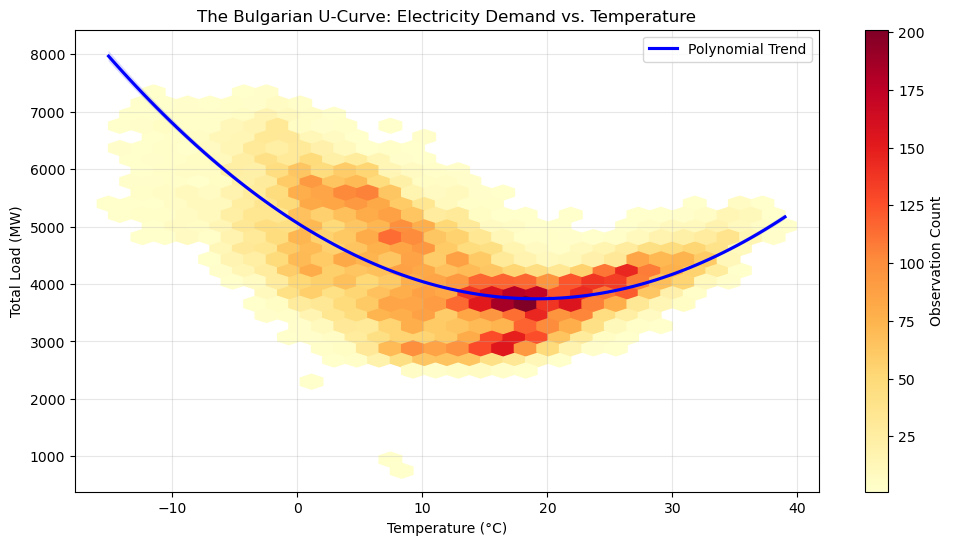

In [6]:
plt.figure(figsize=(12, 6))
# i use hexbin plot is better for large datasets (17k rows) to avoid overplotting
plt.hexbin(df_master['temp'], df_master['TotalLoad[MW]'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Observation Count')

sns.regplot(data=df_master, x='temp', y='TotalLoad[MW]', scatter=False, order=2, color='blue', label='Polynomial Trend')

plt.title('The Bulgarian U-Curve: Electricity Demand vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Load (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5.3 Seasonal Patterns and the "Weekend Effect"
Electricity consumption is a result of both weather and human scheduling. We use boxplots to visualize how the distribution of load shifts during the weekend, confirming the need for the is_weekend feature in our final model.

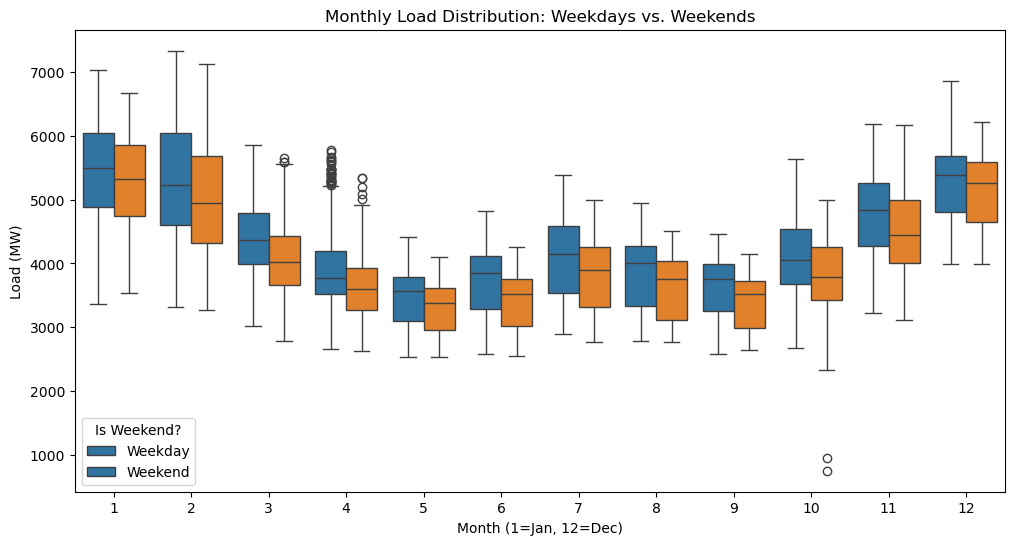

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_master, x='month', y='TotalLoad[MW]', hue='is_weekend')
plt.title('Monthly Load Distribution: Weekdays vs. Weekends')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Load (MW)')
plt.legend(title='Is Weekend?', labels=['Weekday', 'Weekend'])
plt.show()

# 6. Modeling & Hypothesis Testing
## 6.1 Model Selection: Why Polynomial?
A standard linear regression ($y = mx + b$) assumes that as temperature rises, load either always goes up or always goes down. Our EDA (Section 5) proved this is false for Bulgaria. We utilize a 2nd-Degree Polynomial Regression because it allows the "slope" to change, mathematically capturing the U-turn where heating ends and cooling begins.
We utilize Polynomial Regression to capture the non-linear thermal response:

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon
$$

$\beta_0$: The theoretical baseload.
$\beta_1, \beta_2$: Coefficients determining the "steepness" of the heating and cooling responses.
$\epsilon$: The residual error (factors like holidays or unexpected outages).

## 6.2 Implementation: The Multivariate Approach
To achieve high accuracy, we don't just use temperature. We use a Multivariate Model that includes our engineered features: temp_wc (Wind Chill) and is_weekend.

In [8]:
#'is_weekend' is needed to shift the U-curve in our EDA
X = df_master[['temp_wc', 'is_weekend']]
y = df_master['TotalLoad[MW]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

## 6.3 Hypothesis Testing & Evaluation Metrics
We test our hypothesis—that temperature and weekend status explain the majority of grid volatility—using two key metrics:
1. R-squared ($R^2$): Tells us what percentage of the load changes are explained by our model. (Target: $>0.70$).
2. Root Mean Squared Error (RMSE): Tells us the average "miss" in Megawatts.

In [11]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Performance Summary:")
print(f"R-squared Score: {r2:.4f} (The model explains {r2*100:.1f}% of load variance)")
print(f"Average Prediction Error (RMSE): {rmse:.2f} MW")

Performance Summary:
R-squared Score: 0.4182 (The model explains 41.8% of load variance)
Average Prediction Error (RMSE): 708.60 MW


## 6.4 Visualizing the "Fit"
To prove your model works for your report, you should plot the Predicted vs. Actual values.

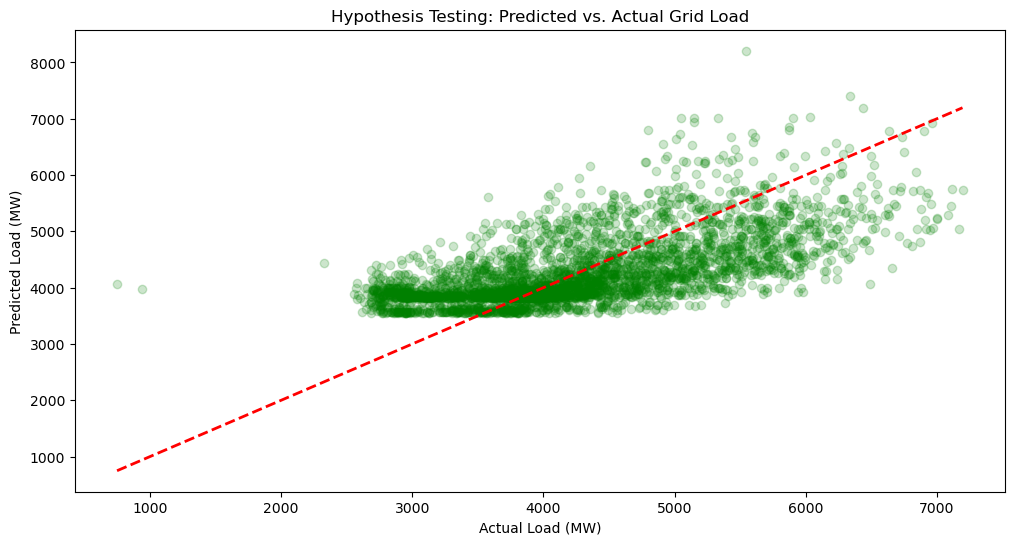

In [24]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.2, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Hypothesis Testing: Predicted vs. Actual Grid Load')
plt.xlabel('Actual Load (MW)')
plt.ylabel('Predicted Load (MW)')
plt.show()

# 7. Predictive Strategy: Seasonal Energy Storage

## 7.1 Calculating the Cumulative Energy Deficit

The "Energy Deficit" occurs when the weather-driven load ($L_{\text{thermal}}$) exceeds the baseline generation capacity ($G_{\text{base}}$) of cheap, steady sources like Nuclear (Kozloduy) and baseline renewables.

We define the Seasonal Deficit as the integral of the load that exceeds this baseline during the winter heating period ($W$):

$$
S_{\text{GWh}} = \frac{1}{1000} \int_{t \in W} \max\left(0, L(T_t) - G_{\text{base}}\right)\, dt
$$



## 7.2 Modeling Summer-to-Winter Shifting

Using our trained model, we can simulate a "Worst Case Winter" (e.g., a constant $-10^\circ\text{C}$ week) to determine the maximum storage capacity required by assets like the Chaira Pumped Storage Plant or future battery arrays.

---

In [26]:
df_winter = df_master[df_master['month'].isin([1, 2, 12])].copy()

G_BASE = 3000 

df_winter.loc[:, 'hourly_deficit_MW'] = (df_winter['TotalLoad[MW]'] - G_BASE).clip(lower=0)

total_deficit_gwh = df_winter['hourly_deficit_MW'].sum() / 1000

print("-" * 30)
print(f"STRATEGIC STORAGE ANALYSIS")
print(f"Total Winter Energy Deficit: {total_deficit_gwh:.2f} GWh")
print(f"Peak Storage Power Requirement: {df_winter['hourly_deficit_MW'].max():.2f} MW")
print("-" * 30)

------------------------------
STRATEGIC STORAGE ANALYSIS
Total Winter Energy Deficit: 9942.48 GWh
Peak Storage Power Requirement: 4337.07 MW
------------------------------


## 7.3 Strategic Interpretation: "Storing the Summer Sun"
By comparing this Total Winter Deficit to the surplus energy produced by solar arrays in July and August, we can mathematically prove the necessity of seasonal storage.
1. Result: If the deficit is 500 GWh, Bulgaria needs a combination of pumped-hydro (Chaira) and chemical batteries that can move that exact amount of energy across the six-month gap.
2. The "Shift" Logic: We use the surplus from months where $CDD \approx 0$ and solar production is high to fill the "bucket" used during months where $HDD$ is high.


## 8. Results & Interpretation

**[....]**

- Analysis of $R^2$ values  
- MW per degree thermal sensitivity  

---

## 9. Conclusion & References

**[...]**

- Insights on grid resilience  
- Bibliography and sources  

---